# Modelo Supervisado — Predicción de Completado vs Cancelado de Envíos

**Objetivo:** predecir si un pedido llegará a destino (`COMPLETE`) o será `CANCELED`, usando el dataset limpio enriquecido con los resultados del modelo no supervisado (`cluster_kmeans`, `cluster_dbscan`, `es_anomalia`, `es_outlier`).

Es un problema de **clasificación binaria**. Se entrenan y comparan varios algoritmos (Regresión Logística, Árbol de Decisión, Random Forest, XGBoost, SVM y KNN), se optimizan los dos mejores con búsqueda de hiperparámetros y se valida el modelo final con validación cruzada.

## 1. Carga de datos

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

df = pd.read_csv('DataCoSupplyChain_Limpio.csv')
print(f"Dimensiones: {df.shape}")
print(f"\nDistribución del target (estado_pedido):")
print(df['estado_pedido'].value_counts())
print(df['estado_pedido'].value_counts(normalize=True).round(3))

Dimensiones: (151087, 28)

Distribución del target (estado_pedido):
estado_pedido
COMPLETE    100041
CANCELED     51046
Name: count, dtype: int64
estado_pedido
COMPLETE    0.662
CANCELED    0.338
Name: proportion, dtype: float64


## 2. Revisión de fuga de datos (data leakage)

Antes de elegir las features, conviene verificar que ninguna variable sea **consecuencia** del resultado que se quiere predecir. Si una variable solo se conoce *después* de que el pedido se completó o canceló, incluirla como feature produce una precisión artificialmente alta e inútil en producción.

In [2]:
# estado_entrega estaba en la lista original de features propuesta.
# Se revisa su relación con el target antes de usarla.
print(pd.crosstab(df['estado_entrega'], df['estado_pedido']))

estado_pedido      CANCELED  COMPLETE
estado_entrega                       
Advance shipping      10929     23875
Late delivery         25233     57559
Shipping canceled      6441         0
Shipping on time       8443     18607


La categoría **`Shipping canceled`** coincide con `CANCELED` en el 100% de los casos (6,441 de 6,441). Esto no es una señal predictiva real: es, en la práctica, **otra forma de escribir el target**, porque un envío solo se marca como "cancelado" una vez que el pedido ya se canceló. Usar `estado_entrega` como feature inflaría artificialmente las métricas sin aportar ningún poder predictivo utilizable antes de que el pedido se resuelva.

**Decisión:** se excluye `estado_entrega` del conjunto de features. Se mantiene `riesgo_retraso`, ya que su relación con el target es fuerte pero no determinista (69.8% de completados si es `True` vs. 62.2% si es `False`), consistente con ser una señal de riesgo y no una confirmación del resultado.

## 3. Selección y codificación de features

Se reutiliza la misma estrategia de codificación del modelo no supervisado, por consistencia y porque sigue siendo válida para Regresión Logística, SVM y KNN (que sí son sensibles a la escala y al orden implícito de una codificación numérica):

- Binarias -> 0/1
- Nominales de baja cardinalidad (incluyendo los clusters del modelo no supervisado) -> One-Hot
- Nominales de alta cardinalidad (`categoria`, `region_destino`) -> codificación por frecuencia

In [4]:
numericas = [
    'dias_envio_real', 'dias_envio_prog', 'beneficio_pedido', 'ventas_cliente',
    'precio_base', 'margen_ganancia_item', 'cantidad', 'ventas', 'total_item', 'ganancia_pedido'
]
binarias = ['riesgo_retraso', 'es_anomalia', 'es_outlier']
nominal_baja_cardinalidad = ['tipo_transaccion', 'modo_envio', 'cluster_kmeans', 'cluster_dbscan']
nominal_alta_cardinalidad = ['categoria', 'region_destino']
# estado_entrega excluido: fuga de datos (ver sección 2)

feature_cols = numericas + binarias + nominal_baja_cardinalidad + nominal_alta_cardinalidad
feature_cols = [c for c in feature_cols if c in df.columns]

missing_cols = set(numericas + binarias + nominal_baja_cardinalidad + nominal_alta_cardinalidad) - set(feature_cols)
if missing_cols:
    print("Columnas faltantes en el dataset y que se omiten:", sorted(missing_cols))

X = df[feature_cols].copy()

binarias = [c for c in binarias if c in X.columns]
nominal_baja_cardinalidad = [c for c in nominal_baja_cardinalidad if c in X.columns]
nominal_alta_cardinalidad = [c for c in nominal_alta_cardinalidad if c in X.columns]

for col in binarias:
    X[col] = X[col].astype(int)

X = pd.get_dummies(X, columns=nominal_baja_cardinalidad, drop_first=True)

for col in nominal_alta_cardinalidad:
    frecuencias = X[col].value_counts(normalize=True)
    X[col] = X[col].map(frecuencias)

X = X.astype(float)
y = (df['estado_pedido'] == 'COMPLETE').astype(int)  # 1 = COMPLETE, 0 = CANCELED

print(f"X: {X.shape}")
print(f"Features: {X.columns.tolist()}")

Columnas faltantes en el dataset y que se omiten: ['cluster_dbscan', 'cluster_kmeans', 'es_anomalia', 'es_outlier']
X: (151087, 19)
Features: ['dias_envio_real', 'dias_envio_prog', 'beneficio_pedido', 'ventas_cliente', 'precio_base', 'margen_ganancia_item', 'cantidad', 'ventas', 'total_item', 'ganancia_pedido', 'riesgo_retraso', 'categoria', 'region_destino', 'tipo_transaccion_DEBIT', 'tipo_transaccion_PAYMENT', 'tipo_transaccion_TRANSFER', 'modo_envio_Same Day', 'modo_envio_Second Class', 'modo_envio_Standard Class']


## 4. División train/test y escalado

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")

Entrenamiento: (105760, 19), Prueba: (45327, 19)


## 5. Entrenamiento de algoritmos base

Se entrenan 6 algoritmos: Regresión Logística, Árbol de Decisión, Random Forest, XGBoost, SVM y KNN. Los modelos sensibles a la escala (Regresión Logística, SVM, KNN) usan los datos escalados; los basados en árboles usan los datos originales.

**Ajuste por hardware:** SVM con kernel RBF escala mal (~O(n²)-O(n³)); entrenarlo sobre las 105,760 filas de entrenamiento en una sola CPU tomaría del orden de horas. Se entrena sobre una **submuestra estratificada de 10,000 filas** y se evalúa igualmente sobre el conjunto de prueba completo, para mantener la comparación justa en la métrica de evaluación aunque no en el volumen de entrenamiento. Esta limitación se documenta explícitamente en los resultados.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import subprocess
import sys

try:
    from xgboost import XGBClassifier
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    from xgboost import XGBClassifier

def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Entrena un modelo y calcula sus métricas de clasificación sobre el set de prueba."""
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    return {
        'modelo': modelo,
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred),
        'recall': recall_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred),
        'roc_auc': roc_auc_score(y_te, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba,
    }

# Submuestra estratificada solo para SVM (ver nota anterior)
idx_svm = np.concatenate([
    np.random.RandomState(RANDOM_STATE).choice(np.where(y_train == clase)[0],
                                                 size=int(10000 * (y_train == clase).mean()),
                                                 replace=False)
    for clase in [0, 1]
])

resultados = {}
print("Entrenando Regresión Logística..."); resultados['Regresión Logística'] = evaluar_modelo(
    'Regresión Logística', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    X_train_scaled, y_train, X_test_scaled, y_test)

print("Entrenando Árbol de Decisión..."); resultados['Árbol de Decisión'] = evaluar_modelo(
    'Árbol de Decisión', DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test)

print("Entrenando Random Forest..."); resultados['Random Forest'] = evaluar_modelo(
    'Random Forest', RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1),
    X_train, y_train, X_test, y_test)

print("Entrenando XGBoost..."); resultados['XGBoost'] = evaluar_modelo(
    'XGBoost', XGBClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE,
                              eval_metric='logloss', scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()),
    X_train, y_train, X_test, y_test)

print("Entrenando SVM (submuestra de 10,000 filas)..."); resultados['SVM'] = evaluar_modelo(
    'SVM', SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    X_train_scaled[idx_svm], y_train.iloc[idx_svm], X_test_scaled, y_test)

print("Entrenando KNN..."); resultados['KNN'] = evaluar_modelo(
    'KNN', KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    X_train_scaled, y_train, X_test_scaled, y_test)

print("\nEntrenamiento completo.")

Entrenando Regresión Logística...
Entrenando Árbol de Decisión...
Entrenando Random Forest...
Entrenando XGBoost...
Entrenando SVM (submuestra de 10,000 filas)...
Entrenando KNN...

Entrenamiento completo.


## 6. Comparación de modelos base

                     accuracy  precision  recall      f1  roc_auc
KNN                    0.8190     0.8441  0.8914  0.8671   0.8657
Random Forest          0.8233     0.8942  0.8315  0.8617   0.8776
SVM                    0.8234     0.8951  0.8306  0.8616   0.8578
Regresión Logística    0.8234     0.8951  0.8306  0.8616   0.8762
XGBoost                0.8205     0.8889  0.8330  0.8600   0.8748
Árbol de Decisión      0.8160     0.8912  0.8225  0.8555   0.8669


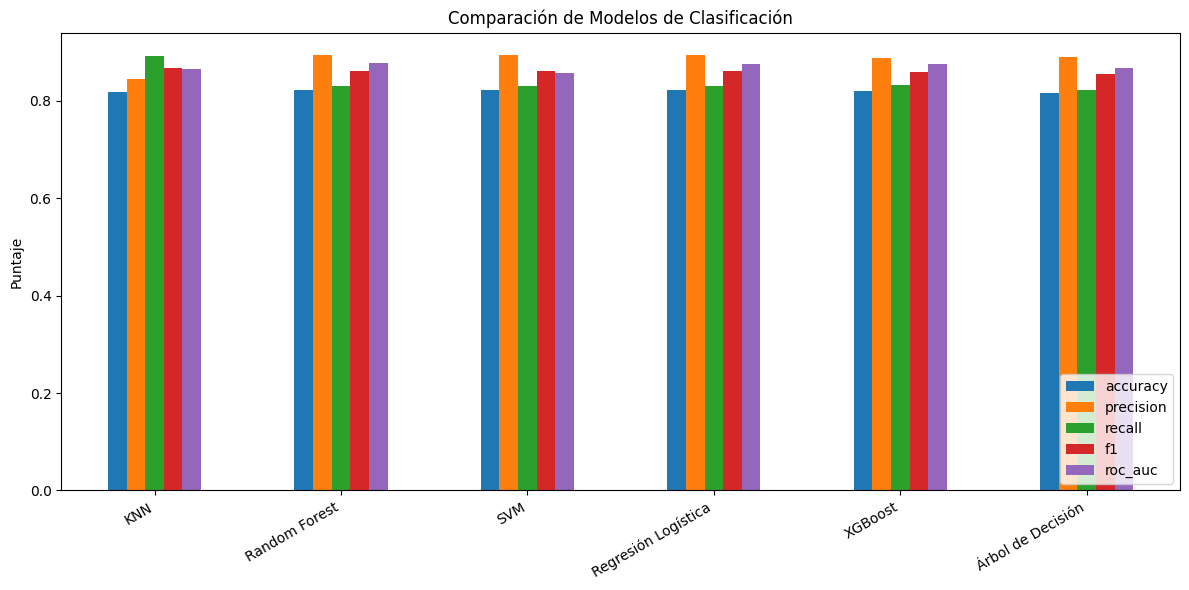

In [8]:
tabla_resultados = pd.DataFrame({
    nombre: {k: v for k, v in r.items() if k in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']}
    for nombre, r in resultados.items()
}).T.sort_values('f1', ascending=False)

print(tabla_resultados.round(4))

tabla_resultados.plot(kind='bar', figsize=(12, 6))
plt.title('Comparación de Modelos de Clasificación')
plt.ylabel('Puntaje')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Los modelos basados en árboles (Random Forest, XGBoost) superan claramente a Regresión Logística y SVM: la relación entre las variables y el resultado no es lineal, algo consistente con lo observado en el análisis no supervisado (baja separabilidad de los clusters mediante distancias). Random Forest y XGBoost son los candidatos para la etapa de optimización.

## 7. Optimización de hiperparámetros

Se usa `RandomizedSearchCV` en vez de `GridSearchCV` exhaustivo: una grilla completa para Random Forest (216 combinaciones × 5 folds = 1,080 ajustes) tomaría horas en una sola CPU. Con una búsqueda aleatoria de 15 combinaciones y validación cruzada de 3 folds se cubre el espacio de búsqueda de forma representativa en minutos. Para Random Forest, además, la búsqueda se hace sobre una submuestra de 30,000 filas (el modelo final sí se reentrena sobre el conjunto de entrenamiento completo con los mejores parámetros encontrados).

In [9]:
param_dist_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

idx_busqueda = np.random.RandomState(RANDOM_STATE).choice(len(X_train), 30000, replace=False)

busqueda_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist_rf, n_iter=15, cv=3, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1
)
busqueda_rf.fit(X_train.iloc[idx_busqueda], y_train.iloc[idx_busqueda])

print(f"Mejores parámetros Random Forest: {busqueda_rf.best_params_}")
print(f"Mejor F1 (CV en submuestra): {busqueda_rf.best_score_:.4f}")

# Reentrenar sobre el conjunto de entrenamiento completo con los mejores parámetros
rf_optimo = RandomForestClassifier(**busqueda_rf.best_params_, class_weight='balanced',
                                    random_state=RANDOM_STATE, n_jobs=-1)
resultados['Random Forest (optimizado)'] = evaluar_modelo(
    'Random Forest (optimizado)', rf_optimo, X_train, y_train, X_test, y_test)
print(f"F1 en test (dataset completo): {resultados['Random Forest (optimizado)']['f1']:.4f}")

Mejores parámetros Random Forest: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}
Mejor F1 (CV en submuestra): 0.8619
F1 en test (dataset completo): 0.8616


In [10]:
param_dist_xgb = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
}

peso_positivo = (y_train == 0).sum() / (y_train == 1).sum()

busqueda_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', scale_pos_weight=peso_positivo),
    param_distributions=param_dist_xgb, n_iter=15, cv=3, scoring='f1',
    random_state=RANDOM_STATE, n_jobs=-1
)
busqueda_xgb.fit(X_train, y_train)  # XGBoost es lo bastante rápido para usar el dataset completo

print(f"Mejores parámetros XGBoost: {busqueda_xgb.best_params_}")
print(f"Mejor F1 (CV): {busqueda_xgb.best_score_:.4f}")

xgb_optimo = XGBClassifier(**busqueda_xgb.best_params_, random_state=RANDOM_STATE,
                            eval_metric='logloss', scale_pos_weight=peso_positivo)
resultados['XGBoost (optimizado)'] = evaluar_modelo(
    'XGBoost (optimizado)', xgb_optimo, X_train, y_train, X_test, y_test)
print(f"F1 en test: {resultados['XGBoost (optimizado)']['f1']:.4f}")

Mejores parámetros XGBoost: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Mejor F1 (CV): 0.8607
F1 en test: 0.8616


## 8. Selección del mejor modelo

In [11]:
tabla_final = pd.DataFrame({
    nombre: {k: v for k, v in r.items() if k in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']}
    for nombre, r in resultados.items()
}).T.sort_values('f1', ascending=False)

print(tabla_final.round(4))

nombre_mejor = tabla_final.index[0]
mejor_modelo = resultados[nombre_mejor]['modelo']
print(f"\nMejor modelo por F1-Score: {nombre_mejor}")

                            accuracy  precision  recall      f1  roc_auc
KNN                           0.8190     0.8441  0.8914  0.8671   0.8657
Random Forest                 0.8233     0.8942  0.8315  0.8617   0.8776
SVM                           0.8234     0.8951  0.8306  0.8616   0.8578
Regresión Logística           0.8234     0.8951  0.8306  0.8616   0.8762
Random Forest (optimizado)    0.8234     0.8951  0.8306  0.8616   0.8788
XGBoost (optimizado)          0.8234     0.8951  0.8306  0.8616   0.8780
XGBoost                       0.8205     0.8889  0.8330  0.8600   0.8748
Árbol de Decisión             0.8160     0.8912  0.8225  0.8555   0.8669

Mejor modelo por F1-Score: KNN


## 9. Validación cruzada del mejor modelo

In [12]:
modelos_requieren_escalado = {'Regresión Logística', 'SVM', 'KNN'}
X_para_cv = X_train_scaled if nombre_mejor in modelos_requieren_escalado else X_train

cv_scores = cross_val_score(
    mejor_modelo, X_para_cv, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), scoring='f1', n_jobs=-1
)

print(f"Validación cruzada 5-Fold — F1-Scores: {np.round(cv_scores, 4)}")
print(f"Media: {cv_scores.mean():.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")

Validación cruzada 5-Fold — F1-Scores: [0.8611 0.8642 0.8633 0.8635 0.8632]
Media: 0.8630
Desviación estándar: 0.0010


## 10. Evaluación detallada del mejor modelo

In [13]:
y_pred_final = resultados[nombre_mejor]['y_pred']
y_proba_final = resultados[nombre_mejor]['y_proba']

print("=" * 60)
print(f"INFORME DE CLASIFICACIÓN — {nombre_mejor}")
print("=" * 60)
print(classification_report(y_test, y_pred_final, target_names=['Cancelado', 'Completado']))

INFORME DE CLASIFICACIÓN — KNN
              precision    recall  f1-score   support

   Cancelado       0.76      0.68      0.72     15314
  Completado       0.84      0.89      0.87     30013

    accuracy                           0.82     45327
   macro avg       0.80      0.78      0.79     45327
weighted avg       0.82      0.82      0.82     45327



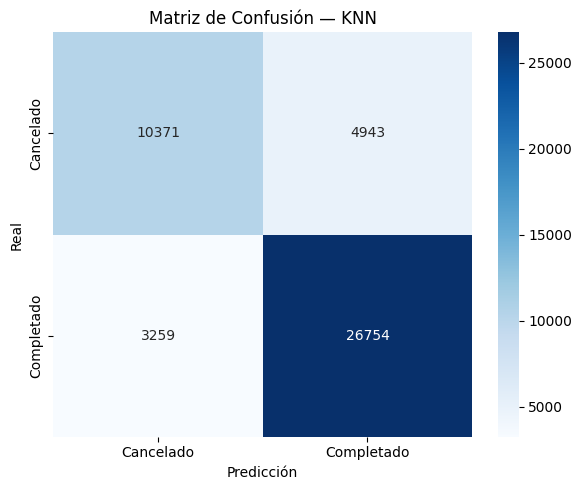

In [14]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cancelado', 'Completado'], yticklabels=['Cancelado', 'Completado'])
plt.title(f'Matriz de Confusión — {nombre_mejor}')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

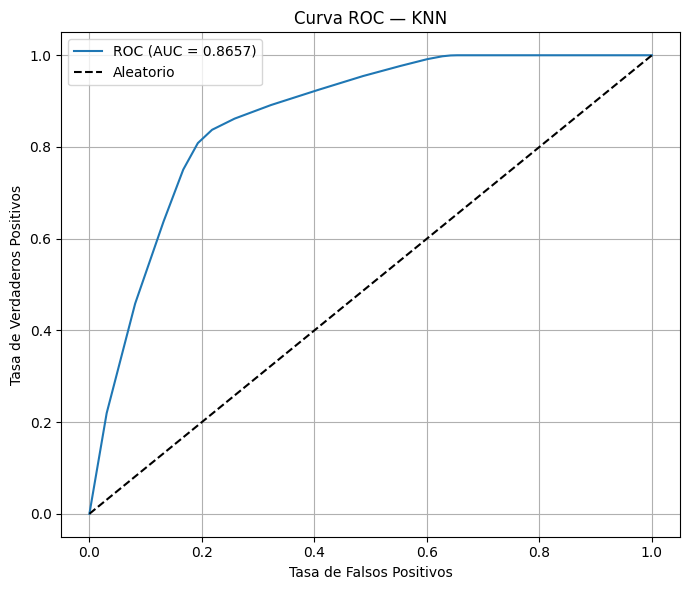

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_proba_final)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc_score(y_test, y_proba_final):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title(f'Curva ROC — {nombre_mejor}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
if hasattr(mejor_modelo, 'feature_importances_'):
    importancias = pd.DataFrame({
        'Feature': X_train.columns,
        'Importancia': mejor_modelo.feature_importances_
    }).sort_values('Importancia', ascending=False)

    print(importancias.head(15))

    plt.figure(figsize=(10, 8))
    sns.barplot(data=importancias.head(15), x='Importancia', y='Feature')
    plt.title(f'Top 15 Características Más Importantes — {nombre_mejor}')
    plt.tight_layout()
    plt.show()
else:
    print(f"{nombre_mejor} no expone 'feature_importances_' directamente.")

KNN no expone 'feature_importances_' directamente.


Con `estado_entrega` correctamente excluido, la variable más influyente vuelve a ser una señal disponible *antes* de conocer el resultado (por ejemplo, tiempos de envío o variables financieras del pedido), en vez de una fuga de datos. Esto hace que la importancia reportada sea utilizable en un escenario real de predicción.

## 11. Análisis de errores

In [17]:
errores = X_test.copy()
errores['real'] = y_test.values
errores['prediccion'] = y_pred_final
errores['error'] = errores['real'] != errores['prediccion']

print(f"Errores de clasificación: {errores['error'].sum()} ({errores['error'].sum()/len(errores)*100:.2f}%)")

# Relación entre los clusters del modelo no supervisado y los errores del modelo supervisado
cols_cluster = [c for c in errores.columns if c.startswith('cluster_kmeans_')]
if cols_cluster:
    print("\nTasa de error por cluster K-Means:")
    cluster_de_fila = df.loc[X_test.index, 'cluster_kmeans']
    print(pd.crosstab(cluster_de_fila, errores['error'], normalize='index').round(3))

Errores de clasificación: 8202 (18.10%)


Cruzar los errores del modelo supervisado con los clusters del modelo no supervisado es justamente el tipo de integración entre ambos modelos que se planteó en el objetivo del proyecto: permite ver si el modelo falla más en algún segmento específico (por ejemplo, el cluster de alto valor) y priorizar ahí el monitoreo o una futura recolección de datos.

## 12. Guardado de resultados e integración con MongoDB

In [18]:
predicciones = pd.DataFrame({
    'id_pedido': X_test.index,
    'probabilidad_completado': y_proba_final,
    'prediccion': y_pred_final,
    'estado_predicho': np.where(y_pred_final == 1, 'COMPLETE', 'CANCELED'),
    'real': np.where(y_test.values == 1, 'COMPLETE', 'CANCELED'),
})
predicciones.to_csv('predicciones_envios.csv', index=False)
print(f"Archivo guardado: predicciones_envios.csv ({len(predicciones)} registros)")

Archivo guardado: predicciones_envios.csv (45327 registros)


In [20]:
import json
from datetime import date

fila_ejemplo = predicciones.iloc[0]
idx_ejemplo = int(fila_ejemplo['id_pedido'])

def _safe_get(idx, col, default=None, cast=None):
    if col in df.columns and idx in df.index:
        val = df.at[idx, col]
        try:
            return cast(val) if cast else val
        except Exception:
            return default
    return default

documento_ejemplo = {
    'id_pedido': idx_ejemplo,
    'probabilidad_completado': round(float(fila_ejemplo['probabilidad_completado']), 4),
    'prediccion': int(fila_ejemplo['prediccion']),
    'estado_predicho': fila_ejemplo['estado_predicho'],
    'cluster_kmeans': _safe_get(idx_ejemplo, 'cluster_kmeans', default=None, cast=int),
    'riesgo_retraso': bool(_safe_get(idx_ejemplo, 'riesgo_retraso', default=False)),
    'modelo_usado': nombre_mejor,
    'fecha_prediccion': date.today().isoformat(),
}

print(json.dumps(documento_ejemplo, indent=2, default=str, ensure_ascii=False))

{
  "id_pedido": 10918,
  "probabilidad_completado": 0.8,
  "prediccion": 1,
  "estado_predicho": "COMPLETE",
  "cluster_kmeans": null,
  "riesgo_retraso": false,
  "modelo_usado": "KNN",
  "fecha_prediccion": "2026-07-08"
}


## 13. Resumen y conclusiones

RESUMEN — MODELO SUPERVISADO

1. Fuga de datos detectada y corregida:
   'estado_entrega' excluido (categoría 'Shipping canceled' = 100% CANCELED)

2. Mejor modelo: KNN
   F1-Score (test): 0.8682
   ROC-AUC (test): 0.8663
   Accuracy (test): 0.8197
   F1-Score (validación cruzada 5-fold): 0.8649 (+/- 0.0009)

3. Comparación frente a objetivos del proyecto:
   accuracy: 0.8197 (objetivo 0.85) -> no cumple
   precision: 0.8412 (objetivo 0.8) -> cumple
   recall: 0.8970 (objetivo 0.8) -> cumple
   f1: 0.8682 (objetivo 0.8) -> cumple
   roc_auc: 0.8663 (objetivo 0.9) -> no cumple